# OULAD Dataset Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path config
DATA_DIR = r'../dataset/'

# Load all tables
assessments       = pd.read_csv(DATA_DIR + 'assessments.csv')
courses           = pd.read_csv(DATA_DIR + 'courses.csv')
student_info      = pd.read_csv(DATA_DIR + 'studentInfo.csv')
student_reg       = pd.read_csv(DATA_DIR + 'studentRegistration.csv')
student_assess    = pd.read_csv(DATA_DIR + 'studentAssessment.csv')
student_vle       = pd.read_csv(DATA_DIR + 'studentVle.csv')
vle               = pd.read_csv(DATA_DIR + 'vle.csv')

tables = {
    'assessments': assessments,
    'courses': courses,
    'studentInfo': student_info,
    'studentRegistration': student_reg,
    'studentAssessment': student_assess,
    'studentVle': student_vle,
    'vle': vle,
}

print("=== Table shapes ===")
for name, df in tables.items():
    print(f"  {name:25s}: {df.shape[0]:>7,} rows × {df.shape[1]} cols")

=== Table shapes ===
  assessments              :     206 rows × 6 cols
  courses                  :      22 rows × 3 cols
  studentInfo              :  32,593 rows × 12 cols
  studentRegistration      :  32,593 rows × 5 cols
  studentAssessment        : 173,912 rows × 5 cols
  studentVle               : 10,655,280 rows × 6 cols
  vle                      :   6,364 rows × 6 cols


## 1. Dataset Overview

── Enrolment Count by Module × Presentation ──


code_presentation,2013B,2013J,2014B,2014J,Total
code_module,,,,,
AAA,0,383,0,365,748
BBB,1767,2237,1613,2292,7909
CCC,0,0,1936,2498,4434
DDD,1303,1938,1228,1803,6272
EEE,0,1052,694,1188,2934
FFF,1614,2283,1500,2365,7762
GGG,0,952,833,749,2534
Total,4684,8845,7804,11260,32593


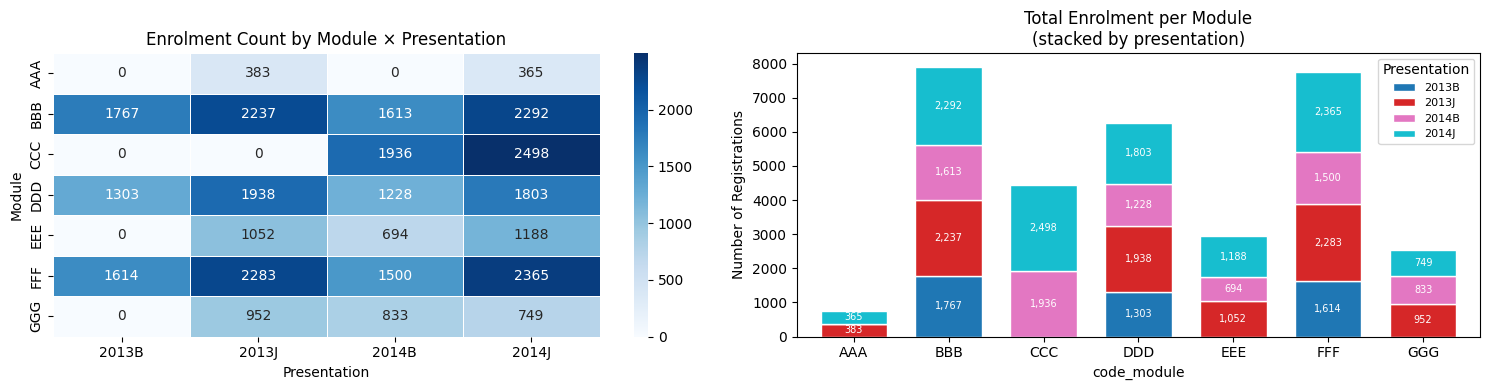

In [23]:

# ── Enrolment Count by Module × Presentation ──────────────────
enrol = (student_info
    .groupby(['code_module', 'code_presentation'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['2013B', '2013J', '2014B', '2014J'], fill_value=0))

enrol['Total'] = enrol.sum(axis=1)
enrol.loc['Total'] = enrol.sum()

print("── Enrolment Count by Module × Presentation ──")
display(enrol)

# ── Heatmap + stacked bar ──────────────────────────────────────
enrol_heat = enrol.drop(index='Total').drop(columns='Total')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.heatmap(enrol_heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Enrolment Count by Module × Presentation')
axes[0].set_xlabel('Presentation')
axes[0].set_ylabel('Module')

enrol_heat.plot(kind='bar', stacked=True, ax=axes[1],
                colormap='tab10', edgecolor='white', width=0.7)
axes[1].set_title('Total Enrolment per Module\n(stacked by presentation)')
axes[1].set_ylabel('Number of Registrations')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Presentation', fontsize=8)
for p in axes[1].patches:
    h = p.get_height()
    if h > 300:
        axes[1].text(p.get_x() + p.get_width()/2, p.get_y() + h/2,
                     f'{int(h):,}', ha='center', va='center', fontsize=7, color='white')

plt.tight_layout()
plt.show()


## 2. Data Cleaning

In [8]:
# ── 2.1 Missing value audit across all 7 tables ──────────────
print("=" * 60)
print("MISSING VALUE AUDIT — ALL 7 TABLES")
print("=" * 60)

all_tables = {
    'assessments':         assessments,
    'courses':             courses,
    'studentInfo':         student_info,
    'studentRegistration': student_reg,
    'studentAssessment':   student_assess,
    'studentVle':          student_vle,
    'vle':                 vle,
}

audit_rows = []
for tname, df in all_tables.items():
    for col in df.columns:
        n_miss = df[col].isnull().sum()
        audit_rows.append({
            'Table':   tname,
            'Column':  col,
            'Missing': int(n_miss),
            '%':       round(n_miss / len(df) * 100, 2),
            'dtype':   str(df[col].dtype),
        })

audit_df = pd.DataFrame(audit_rows)
has_missing = audit_df[audit_df['Missing'] > 0].reset_index(drop=True)
if len(has_missing) > 0:
    print(f"Columns with missing values ({len(has_missing)} found):")
    display(has_missing)
else:
    print("No missing values found in any table.")

print("\n── Summary: total rows per table ──")
for tname, df in all_tables.items():
    total_miss = df.isnull().sum().sum()
    print(f"  {tname:22s}: {len(df):>8,} rows × {df.shape[1]} cols  |  missing cells: {total_miss}")


MISSING VALUE AUDIT — ALL 7 TABLES
Columns with missing values (7 found):


,Table,Column,Missing,%,dtype
0,assessments,date,11,5.34,float64
1,studentInfo,imd_band,1111,3.41,str
2,studentRegistration,date_registration,45,0.14,float64
3,studentRegistration,date_unregistration,22521,69.10,float64
4,studentAssessment,score,173,0.10,float64
5,vle,week_from,5243,82.39,float64
6,vle,week_to,5243,82.39,float64



── Summary: total rows per table ──
  assessments           :      206 rows × 6 cols  |  missing cells: 11
  courses               :       22 rows × 3 cols  |  missing cells: 0
  studentInfo           :   32,593 rows × 12 cols  |  missing cells: 1111
  studentRegistration   :   32,593 rows × 5 cols  |  missing cells: 22566
  studentAssessment     :  173,912 rows × 5 cols  |  missing cells: 173
  studentVle            : 10,655,280 rows × 6 cols  |  missing cells: 0
  vle                   :    6,364 rows × 6 cols  |  missing cells: 10486


In [3]:
# ── 2.2 Handle missing values & document decisions (all 7 tables)

# ── assessments: date ─────────────────────────────────────────
# 'date' is null for 11 Exam-type assessments — by OULAD design,
# exams have no fixed VLE submission date. Retain NaN; add flag.
assessments_clean = assessments.copy()
assessments_clean['has_date'] = assessments_clean['date'].notna().astype(int)

# ── courses: no missing values ────────────────────────────────
courses_clean = courses.copy()

# ── studentInfo: imd_band ─────────────────────────────────────
# imd_band missing ~3.4% of rows. Treated as a distinct category
# 'Unknown' rather than imputing, because missingness may be
# non-random (lower-income students less likely to disclose).
student_info_clean = student_info.copy()
student_info_clean['imd_band'] = student_info_clean['imd_band'].fillna('Unknown')

# ── studentRegistration: date_registration / date_unregistration
# date_registration: 45 nulls (0.14%) — likely late/admin
#   registrations with no date recorded. Fill with 0 (course start)
#   as a conservative assumption; flagged with a boolean.
# date_unregistration: null = did not withdraw (structural, not missing).
#   Add a boolean flag for convenience.
student_reg_clean = student_reg.copy()
student_reg_clean['reg_date_imputed'] = student_reg_clean['date_registration'].isna().astype(int)
student_reg_clean['date_registration'] = student_reg_clean['date_registration'].fillna(0)
student_reg_clean['unregistered'] = student_reg_clean['date_unregistration'].notna().astype(int)

# ── studentAssessment: score ──────────────────────────────────
# Null score = student did not submit. Non-submission is a
# behavioural signal correlated with withdrawal; retain as flag.
student_assess_clean = student_assess.copy()
student_assess_clean['submitted'] = student_assess_clean['score'].notna().astype(int)
student_assess_clean['score'] = student_assess_clean['score'].fillna(0)

# ── studentVle: no missing values ─────────────────────────────
student_vle_clean = student_vle.copy()

# ── vle: week_from / week_to ──────────────────────────────────
# 82.4% of VLE resources have no week_from/week_to metadata —
# these are optional scheduling fields not used in feature
# engineering. Retain as NaN; not used downstream.
vle_clean = vle.copy()

# ── Summary of cleaning decisions ─────────────────────────────
print("── Cleaning Decisions (all 7 tables) ──\n")
decisions = pd.DataFrame([
    ('assessments',        'date',                  'Null = Exam type (by design); added has_date flag (0/1)'),
    ('courses',            'all cols',               'No missing values'),
    ('studentInfo',        'imd_band',               "fillna('Unknown') — treat as separate category (3.4% missing)"),
    ('studentInfo',        'all other cols',         'No missing values'),
    ('studentRegistration','date_registration',      'fillna(0) = course start; added reg_date_imputed flag (45 rows)'),
    ('studentRegistration','date_unregistration',    'Null = did not withdraw (structural); added unregistered flag'),
    ('studentAssessment',  'score',                  'fillna(0) — non-submission scored as 0; added submitted flag'),
    ('studentVle',         'all cols',               'No missing values'),
    ('vle',                'week_from / week_to',    'Null = optional metadata, not used in feature engineering — retained'),
], columns=['Table', 'Column', 'Action'])
display(decisions)

# ── Post-cleaning audit ───────────────────────────────────────
print("\n── Post-cleaning missing value check ──")
intentional_nulls = {
    'assessments_clean':       ['date'],
    'studentReg_clean':        ['date_unregistration'],
    'vle_clean':               ['week_from', 'week_to'],
}
clean_tables = [
    ('assessments_clean',       assessments_clean),
    ('courses_clean',           courses_clean),
    ('studentInfo_clean',       student_info_clean),
    ('studentReg_clean',        student_reg_clean),
    ('studentAssessment_clean', student_assess_clean),
    ('studentVle_clean',        student_vle_clean),
    ('vle_clean',               vle_clean),
]
all_ok = True
for name, df in clean_tables:
    skip = intentional_nulls.get(name, [])
    check_cols = [c for c in df.columns if c not in skip]
    n_miss = df[check_cols].isnull().sum().sum()
    status = 'OK' if n_miss == 0 else f'WARNING: {n_miss} unexpected nulls'
    print(f"  {name:30s}: {status}")
    if n_miss > 0:
        all_ok = False
if all_ok:
    print("\nAll tables clean — no unexpected missing values.")

# ── Overwrite raw variables so all downstream cells use clean data
assessments    = assessments_clean
courses        = courses_clean
student_info   = student_info_clean
student_reg    = student_reg_clean
student_assess = student_assess_clean
student_vle    = student_vle_clean
vle            = vle_clean
print("All 7 raw variables reassigned to cleaned versions.")


── Cleaning Decisions (all 7 tables) ──



,Table,Column,Action
0,assessments,date,Null = Exam type (by design); added has_date f...
1,courses,all cols,No missing values
2,studentInfo,imd_band,fillna('Unknown') — treat as separate category...
3,studentInfo,all other cols,No missing values
4,studentRegistration,date_registration,fillna(0) = course start; added reg_date_imput...
5,studentRegistration,date_unregistration,Null = did not withdraw (structural); added un...
6,studentAssessment,score,fillna(0) — non-submission scored as 0; added ...
7,studentVle,all cols,No missing values
8,vle,week_from / week_to,"Null = optional metadata, not used in feature ..."



── Post-cleaning missing value check ──
  assessments_clean             : OK
  courses_clean                 : OK
  studentInfo_clean             : OK
  studentReg_clean              : OK
  studentAssessment_clean       : OK
  studentVle_clean              : OK
  vle_clean                     : OK

All tables clean — no unexpected missing values.
All 7 raw variables reassigned to cleaned versions.


In [10]:
# ── 2.3 Export all cleaned tables ────────────────────────────
import os

CLEAN_DIR = r'../dataset/cleaned/'
os.makedirs(CLEAN_DIR, exist_ok=True)

export_map = {
    'assessments_clean.csv':         assessments,
    'courses_clean.csv':             courses,
    'studentInfo_clean.csv':         student_info,
    'studentRegistration_clean.csv': student_reg,
    'studentAssessment_clean.csv':   student_assess,
    'studentVle_clean.csv':          student_vle,
    'vle_clean.csv':                 vle,
}

print("Cleaned files saved to", CLEAN_DIR)
for fname, df in export_map.items():
    path = CLEAN_DIR + fname
    df.to_csv(path, index=False)
    df_check = pd.read_csv(path)
    print(f"  {fname:38s}: {df_check.shape[0]:>8,} rows × {df_check.shape[1]} cols")


Cleaned files saved to ../dataset/cleaned/
  assessments_clean.csv                 :      206 rows × 7 cols
  courses_clean.csv                     :       22 rows × 3 cols
  studentInfo_clean.csv                 :   32,593 rows × 12 cols
  studentRegistration_clean.csv         :   32,593 rows × 7 cols
  studentAssessment_clean.csv           :  173,912 rows × 6 cols
  studentVle_clean.csv                  : 10,655,280 rows × 6 cols
  vle_clean.csv                         :    6,364 rows × 6 cols


## 3. Target Variable: Module Withdrawal

In [27]:
from IPython.display import display

# Basic info
print(f"Shape: {student_info.shape[0]:,} rows × {student_info.shape[1]} cols\n")

# Missing values table
missing = student_info.isnull().sum().rename('Missing').to_frame()
missing['%'] = (missing['Missing'] / len(student_info) * 100).round(2)
print("── Missing Values ──")
display(missing[missing['Missing'] > 0] if missing['Missing'].sum() > 0 else pd.DataFrame({'Note': ['No missing values']}))

# Final result distribution table
print("\n── Final Result Distribution ──")
result_table = student_info['final_result'].value_counts().reset_index()
result_table.columns = ['Final Result', 'Count']
result_table['%'] = (result_table['Count'] / len(student_info) * 100).round(1)
display(result_table)
print(f"\nWithdrawal rate: {(student_info['final_result']=='Withdrawn').mean():.1%}")


Shape: 32,593 rows × 12 cols

── Missing Values ──


,Note
0,No missing values



── Final Result Distribution ──


,Final Result,Count,%
0,Pass,12361,37.9
1,Withdrawn,10156,31.2
2,Fail,7052,21.6
3,Distinction,3024,9.3



Withdrawal rate: 31.2%


── Final Result Distribution by Module (%) ──


final_result,N,Distinction,Fail,Pass,Withdrawn
code_module,,,,,
AAA,748,5.9,12.2,65.1,16.8
BBB,7909,8.6,22.3,38.9,30.2
CCC,4434,11.2,17.6,26.6,44.5
DDD,6272,6.1,22.5,35.5,35.9
EEE,2934,12.1,19.2,44.1,24.6
FFF,7762,8.6,22.0,38.4,31.0
GGG,2534,15.6,28.7,44.1,11.5


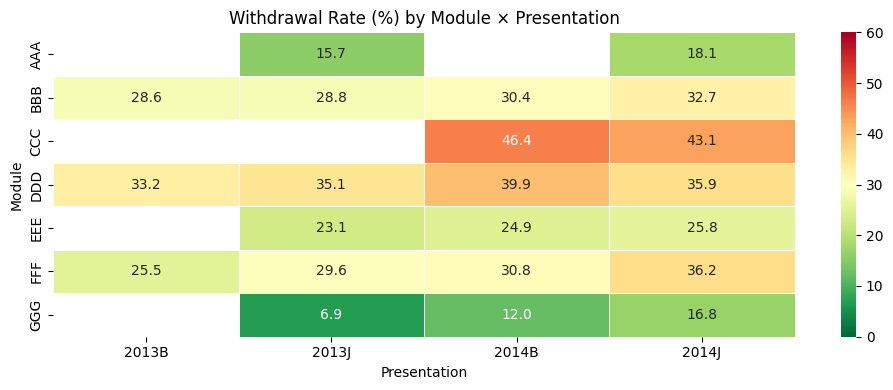

In [28]:
# ── Per-module final result distribution ────────────────────────
module_result = (student_info
    .groupby(['code_module', 'final_result'])
    .size()
    .unstack(fill_value=0))
module_result_pct = module_result.div(module_result.sum(axis=1), axis=0).mul(100).round(1)
module_result_pct.insert(0, 'N', module_result.sum(axis=1))
print("── Final Result Distribution by Module (%) ──")
display(module_result_pct)

# Heatmap: withdrawal rate by module × presentation
pivot_wd = (student_info
    .assign(withdrawn=(student_info['final_result'] == 'Withdrawn').astype(int))
    .groupby(['code_module', 'code_presentation'])['withdrawn']
    .mean().mul(100).round(1)
    .unstack())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_wd, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=60)
ax.set_title('Withdrawal Rate (%) by Module × Presentation')
ax.set_xlabel('Presentation')
ax.set_ylabel('Module')
plt.tight_layout()
plt.show()


## 4. Learner Demographics

── Demographics Summary ──


,Category,Count,%
0,Total students,32593,100.0
1,Female,14718,45.2
2,Male,17875,54.8
3,Pass,12361,37.9
4,Distinction,3024,9.3
5,Fail,7052,21.6
6,Withdrawn,10156,31.2


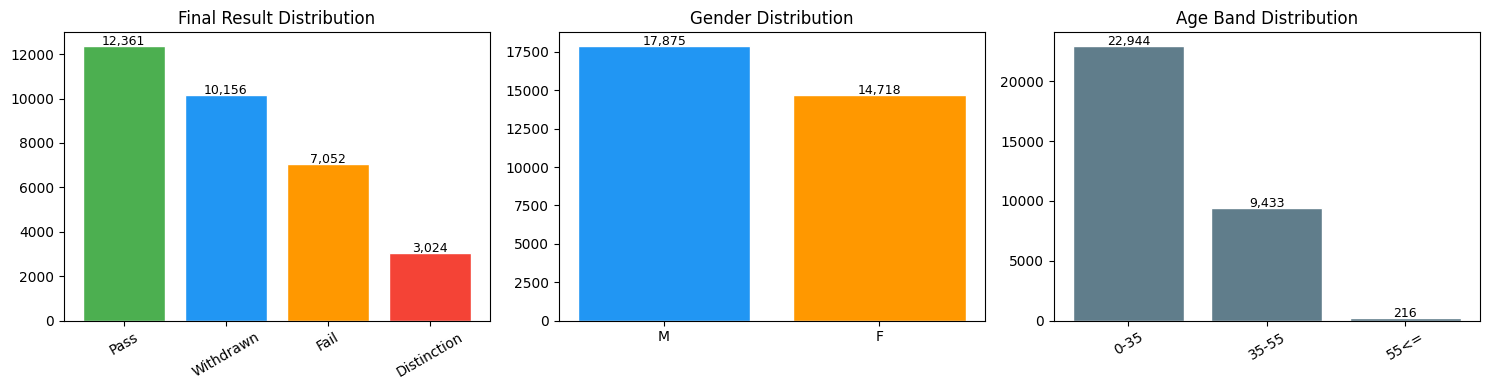

In [29]:
# Summary table
print("── Demographics Summary ──")
demo_table = pd.DataFrame({
    'Category': ['Total students', 'Female', 'Male',
                 'Pass', 'Distinction', 'Fail', 'Withdrawn'],
    'Count': [
        len(student_info),
        (student_info['gender']=='F').sum(),
        (student_info['gender']=='M').sum(),
        (student_info['final_result']=='Pass').sum(),
        (student_info['final_result']=='Distinction').sum(),
        (student_info['final_result']=='Fail').sum(),
        (student_info['final_result']=='Withdrawn').sum(),
    ]
})
demo_table['%'] = (demo_table['Count'] / len(student_info) * 100).round(1)
display(demo_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Final result
result_counts = student_info['final_result'].value_counts()
bars0 = axes[0].bar(result_counts.index, result_counts.values,
                    color=['#4CAF50','#2196F3','#FF9800','#F44336'], edgecolor='white')
axes[0].set_title('Final Result Distribution')
axes[0].tick_params(axis='x', rotation=30)
for b in bars0:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,}', ha='center', fontsize=9)

# Gender
gender_counts = student_info['gender'].value_counts()
bars1 = axes[1].bar(gender_counts.index, gender_counts.values,
                    color=['#2196F3','#FF9800'], edgecolor='white')
axes[1].set_title('Gender Distribution')
for b in bars1:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,}', ha='center', fontsize=9)

# Age band
age_counts = student_info['age_band'].value_counts().sort_index()
bars2 = axes[2].bar(age_counts.index, age_counts.values, color='#607D8B', edgecolor='white')
axes[2].set_title('Age Band Distribution')
axes[2].tick_params(axis='x', rotation=30)
for b in bars2:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 5. VLE Engagement

── studentVle Statistics ──


,Metric,Value
0,Total interaction records,"10,655,280"
1,Students with VLE records,"26,074"
2,Median total clicks / student,824
3,Mean total clicks / student,1519
4,Median active days / student,52
5,Mean active days / student,67


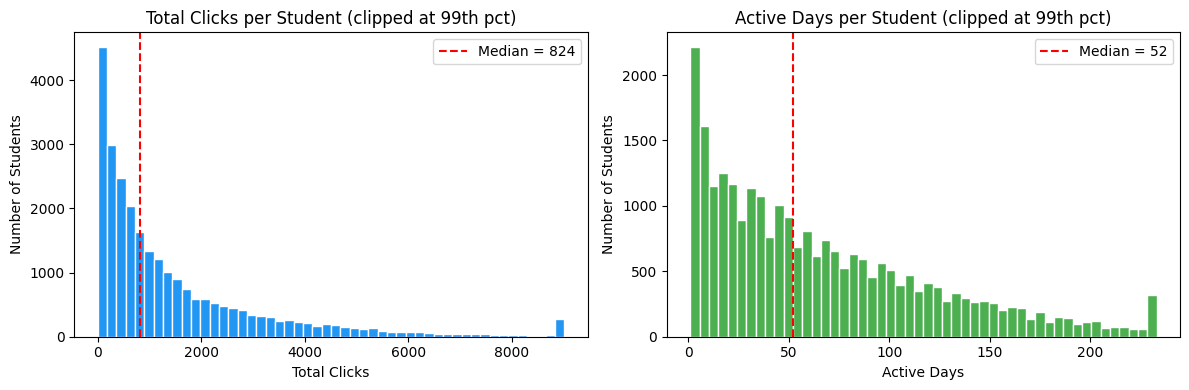

In [30]:
# Aggregate per student
vle_agg = student_vle.groupby('id_student').agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique')
).reset_index()

# Stats table
print("── studentVle Statistics ──")
stats_table = pd.DataFrame({
    'Metric': ['Total interaction records', 'Students with VLE records',
               'Median total clicks / student', 'Mean total clicks / student',
               'Median active days / student', 'Mean active days / student'],
    'Value': [
        f"{len(student_vle):,}",
        f"{len(vle_agg):,}",
        f"{vle_agg['total_clicks'].median():.0f}",
        f"{vle_agg['total_clicks'].mean():.0f}",
        f"{vle_agg['active_days'].median():.0f}",
        f"{vle_agg['active_days'].mean():.0f}",
    ]
})
display(stats_table)

# Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p99_clicks = vle_agg['total_clicks'].quantile(0.99)
p99_days   = vle_agg['active_days'].quantile(0.99)

axes[0].hist(vle_agg['total_clicks'].clip(upper=p99_clicks),
             bins=50, color='#2196F3', edgecolor='white')
axes[0].set_title('Total Clicks per Student (clipped at 99th pct)')
axes[0].set_xlabel('Total Clicks')
axes[0].set_ylabel('Number of Students')
axes[0].axvline(vle_agg['total_clicks'].median(), color='red', linestyle='--',
                label=f"Median = {vle_agg['total_clicks'].median():.0f}")
axes[0].legend()

axes[1].hist(vle_agg['active_days'].clip(upper=p99_days),
             bins=50, color='#4CAF50', edgecolor='white')
axes[1].set_title('Active Days per Student (clipped at 99th pct)')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Number of Students')
axes[1].axvline(vle_agg['active_days'].median(), color='red', linestyle='--',
                label=f"Median = {vle_agg['active_days'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()


── VLE Engagement by Module (students with VLE records only) ──


,n_students,median_clicks,mean_clicks,median_days,mean_days
code_module,,,,,
AAA,702,1262.5,1775.9,81.0,91.5
BBB,6484,454.0,807.2,36.0,47.9
CCC,3852,684.0,1215.5,43.0,56.4
DDD,5407,708.0,1022.8,61.0,72.0
EEE,2634,1229.5,1512.6,63.0,69.3
FFF,6799,2116.0,2587.7,72.0,81.0
GGG,2359,464.0,565.4,30.0,35.7


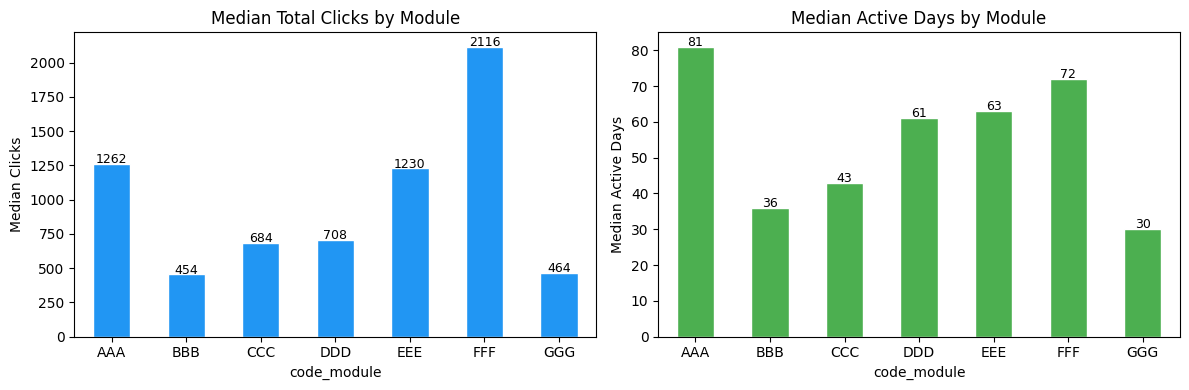

In [31]:
# ── Per-module VLE engagement (students with VLE records only) ──
# student_vle already contains code_module — no merge with student_info needed,
# which avoids inflating records for students registered in multiple modules.
vle_mod = (student_vle
    .groupby(['code_module', 'id_student'])
    .agg(clicks=('sum_click', 'sum'), days=('date', 'nunique'))
    .groupby('code_module')
    .agg(
        n_students=('clicks', 'count'),
        median_clicks=('clicks', 'median'),
        mean_clicks=('clicks', 'mean'),
        median_days=('days', 'median'),
        mean_days=('days', 'mean'),
    )
    .round(1))

print("── VLE Engagement by Module (students with VLE records only) ──")
display(vle_mod)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vle_mod['median_clicks'].plot(kind='bar', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Median Total Clicks by Module')
axes[0].set_ylabel('Median Clicks')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                 f'{p.get_height():.0f}', ha='center', fontsize=9)

vle_mod['median_days'].plot(kind='bar', ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('Median Active Days by Module')
axes[1].set_ylabel('Median Active Days')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.3,
                 f'{p.get_height():.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


── VLE Activity Type Statistics ──


,activity_type,Total_Clicks,Interaction_Records,Click %,Interaction %
0,oucontent,11206803,1963782,28.3,18.4
1,forumng,7973390,2408457,20.1,22.6
2,quiz,6981240,914573,17.6,8.6
3,homepage,6949064,1735226,17.5,16.3
4,subpage,3411582,1949898,8.6,18.3
5,resource,1110132,813185,2.8,7.6
6,ouwiki,894512,178165,2.3,1.7
7,url,566702,407716,1.4,3.8
8,oucollaborate,108974,65793,0.3,0.6
9,glossary,87962,17435,0.2,0.2


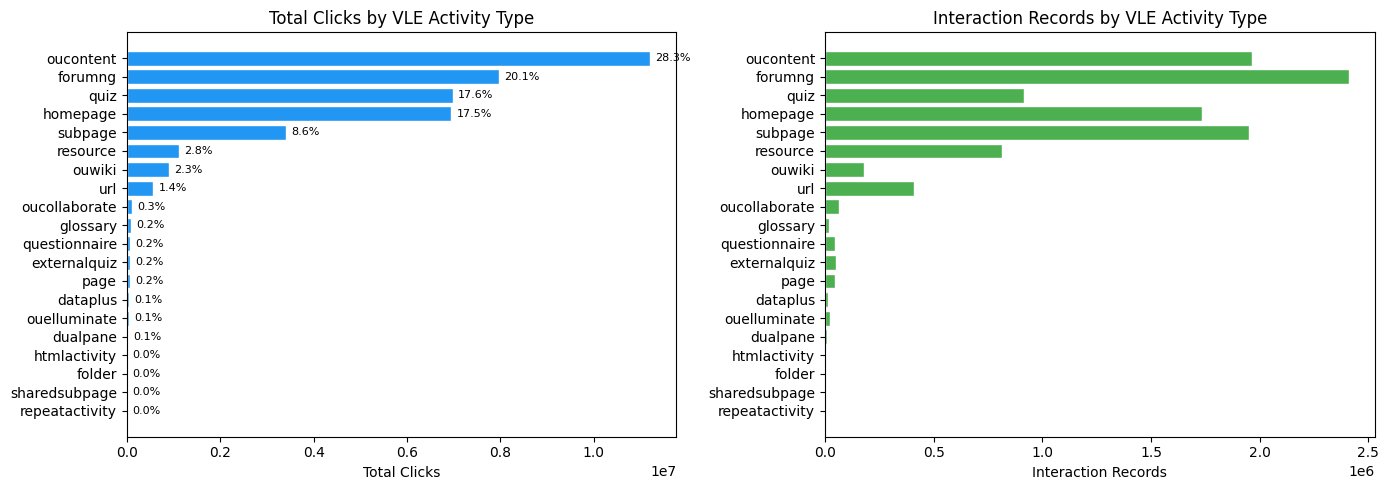

In [32]:

# ── VLE Resource Type Breakdown ───────────────────────────────
# Join student_vle with vle table to get activity_type per interaction
vle_typed = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')

# Total clicks and interaction records by activity type
type_stats = (vle_typed
    .groupby('activity_type')
    .agg(
        Total_Clicks=('sum_click', 'sum'),
        Interaction_Records=('sum_click', 'count'),
    )
    .sort_values('Total_Clicks', ascending=False)
    .reset_index())
type_stats['Click %']       = (type_stats['Total_Clicks'] / type_stats['Total_Clicks'].sum() * 100).round(1)
type_stats['Interaction %'] = (type_stats['Interaction_Records'] / type_stats['Interaction_Records'].sum() * 100).round(1)

print("── VLE Activity Type Statistics ──")
display(type_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(type_stats['activity_type'], type_stats['Total_Clicks'],
             color='#2196F3', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_xlabel('Total Clicks')
axes[0].set_title('Total Clicks by VLE Activity Type')
for i, v in enumerate(type_stats['Total_Clicks']):
    axes[0].text(v + type_stats['Total_Clicks'].max()*0.01, i, f"{type_stats['Click %'].iloc[i]:.1f}%",
                 va='center', fontsize=8)

axes[1].barh(type_stats['activity_type'], type_stats['Interaction_Records'],
             color='#4CAF50', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_xlabel('Interaction Records')
axes[1].set_title('Interaction Records by VLE Activity Type')

plt.tight_layout()
plt.show()


── Mean Clicks & Active Days by Final Result ──


,Final Result,Count,Mean Clicks,Median Clicks,Mean Active Days,Median Active Days
0,Distinction,3024,3106.4,2218.0,118.3,113.0
1,Fail,7052,794.4,387.0,38.1,25.5
2,Pass,12361,2170.6,1503.0,93.2,84.0
3,Withdrawn,10156,628.1,178.0,28.7,12.0


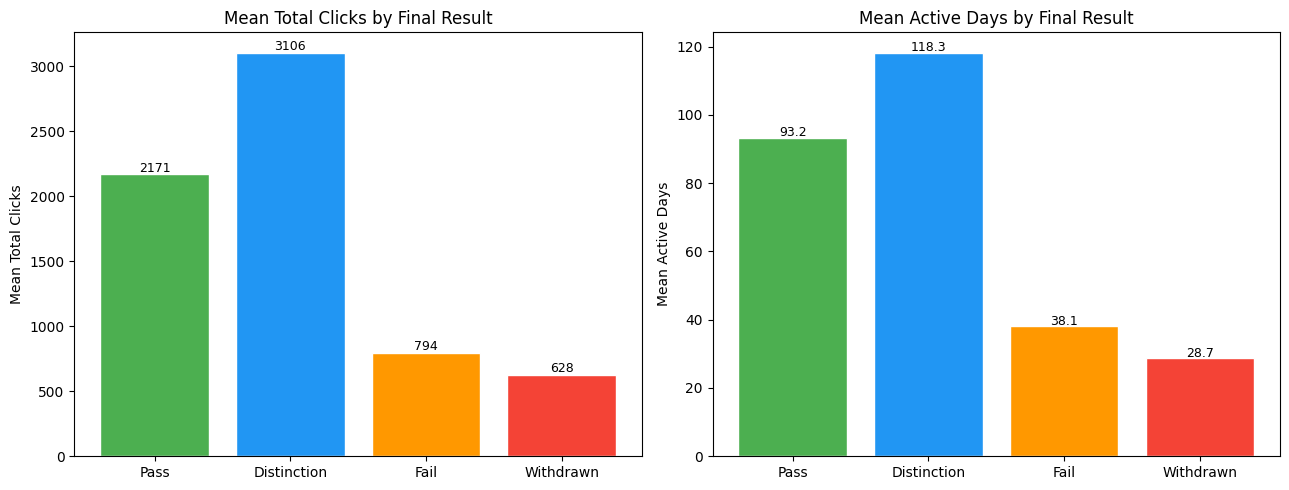

In [33]:
merged = student_info[['id_student', 'final_result']].merge(vle_agg, on='id_student', how='left')
merged['total_clicks'] = merged['total_clicks'].fillna(0)
merged['active_days']  = merged['active_days'].fillna(0)

# Summary table
print("── Mean Clicks & Active Days by Final Result ──")
summary = merged.groupby('final_result').agg(
    Count=('id_student', 'count'),
    Mean_Clicks=('total_clicks', 'mean'),
    Median_Clicks=('total_clicks', 'median'),
    Mean_Active_Days=('active_days', 'mean'),
    Median_Active_Days=('active_days', 'median'),
).round(1).reset_index()
summary.columns = ['Final Result', 'Count', 'Mean Clicks', 'Median Clicks',
                   'Mean Active Days', 'Median Active Days']
display(summary)

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}

means_clicks = [merged[merged['final_result']==r]['total_clicks'].mean() for r in order]
means_days   = [merged[merged['final_result']==r]['active_days'].mean() for r in order]

bars_c = axes[0].bar(order, means_clicks, color=[palette[r] for r in order], edgecolor='white')
axes[0].set_title('Mean Total Clicks by Final Result')
axes[0].set_ylabel('Mean Total Clicks')
for b, v in zip(bars_c, means_clicks):
    axes[0].text(b.get_x()+b.get_width()/2, v+20, f'{v:.0f}', ha='center', fontsize=9)

bars_d = axes[1].bar(order, means_days, color=[palette[r] for r in order], edgecolor='white')
axes[1].set_title('Mean Active Days by Final Result')
axes[1].set_ylabel('Mean Active Days')
for b, v in zip(bars_d, means_days):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [34]:
# ── No-VLE student participation summary ───────────────────────
students_with_vle = set(student_vle['id_student'].unique())
student_info['has_vle'] = student_info['id_student'].isin(students_with_vle)

no_vle  = student_info[~student_info['has_vle']]
has_vle = student_info[student_info['has_vle']]

print("── VLE Participation Summary ──")
summary_vle = pd.DataFrame({
    'Group':           ['Has VLE records', 'No VLE records', 'All students'],
    'Count':           [len(has_vle), len(no_vle), len(student_info)],
    'Withdrawal Rate': [
        f"{(has_vle['final_result']=='Withdrawn').mean():.1%}",
        f"{(no_vle['final_result']=='Withdrawn').mean():.1%}",
        f"{(student_info['final_result']=='Withdrawn').mean():.1%}",
    ]
})
display(summary_vle)

print("\n── Final Result Distribution for No-VLE Students ──")
no_vle_dist = no_vle['final_result'].value_counts().reset_index()
no_vle_dist.columns = ['Final Result', 'Count']
no_vle_dist['%'] = (no_vle_dist['Count'] / len(no_vle) * 100).round(1)
display(no_vle_dist)

student_info.drop(columns=['has_vle'], inplace=True)


── VLE Participation Summary ──


,Group,Count,Withdrawal Rate
0,Has VLE records,29741,25.7%
1,No VLE records,2852,88.2%
2,All students,32593,31.2%



── Final Result Distribution for No-VLE Students ──


,Final Result,Count,%
0,Withdrawn,2516,88.2
1,Fail,333,11.7
2,Pass,3,0.1


In [35]:
# ── No-VLE proportion and withdrawal rate by module ────────────
# Per-module evidence supporting the decision to exclude no-VLE students.
# Key finding: GGG shows notably lower no-VLE withdrawal rate (35–65%)
# vs all other modules (80–97%), indicating lower VLE dependency.
students_with_vle_set = set(student_vle['id_student'].unique())
student_info['has_vle'] = student_info['id_student'].isin(students_with_vle_set)

result = []
for (mod, pres), g in student_info.groupby(['code_module', 'code_presentation']):
    total = len(g)
    no_v  = (~g['has_vle']).sum()
    has_v = g['has_vle'].sum()
    wd_no_v  = (g[~g['has_vle']]['final_result'] == 'Withdrawn').sum()
    wd_has_v = (g[ g['has_vle']]['final_result'] == 'Withdrawn').sum()
    result.append({
        'Module': mod, 'Presentation': pres, 'Total': total,
        'No-VLE N': no_v,
        'No-VLE %': round(no_v / total * 100, 1),
        'WD% (no VLE)':  round(wd_no_v / no_v  * 100, 1) if no_v  > 0 else None,
        'WD% (has VLE)': round(wd_has_v / has_v * 100, 1) if has_v > 0 else None,
    })

pres_order = {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}
df_module_vle = (pd.DataFrame(result)
    .assign(_pres_rank=lambda d: d['Presentation'].map(pres_order))
    .sort_values(['_pres_rank', 'Module'])
    .drop(columns='_pres_rank')
    .reset_index(drop=True))
print("── No-VLE Proportion and Withdrawal Rate by Module (sorted by presentation) ──")
print("Note: Module GGG shows notably lower no-VLE WD rate (35-65%) vs other modules (80-97%)")
display(df_module_vle)

student_info.drop(columns=['has_vle'], inplace=True)


── No-VLE Proportion and Withdrawal Rate by Module (sorted by presentation) ──
Note: Module GGG shows notably lower no-VLE WD rate (35-65%) vs other modules (80-97%)


,Module,Presentation,Total,No-VLE N,No-VLE %,WD% (no VLE),WD% (has VLE)
0,BBB,2013B,1767,219,12.4,79.5,21.4
1,DDD,2013B,1303,76,5.8,81.6,30.2
2,FFF,2013B,1614,93,5.8,90.3,21.5
3,AAA,2013J,383,4,1.0,100.0,14.8
4,BBB,2013J,2237,332,14.8,86.1,18.8
5,DDD,2013J,1938,136,7.0,91.2,30.9
6,EEE,2013J,1052,78,7.4,83.3,18.3
7,FFF,2013J,2283,165,7.2,95.8,24.4
8,GGG,2013J,952,56,5.9,35.7,5.1
9,BBB,2014B,1613,299,18.5,90.3,16.7


## 6. Assessment Behaviour

── Assessment Types in Dataset ──


,Type,Count,%
0,TMA,106,51.5
1,CMA,76,36.9
2,Exam,24,11.7



── Submission Rate by Final Result ──


,final_result,Total_Records,Submitted,Submission Rate (%)
0,Distinction,30344,30343,100.0
1,Fail,32976,32894,99.8
2,Pass,118025,117985,100.0
3,Withdrawn,25974,25870,99.6



── Mean Score (submitted only) by Assessment Type × Final Result ──


assessment_type,CMA,Exam,TMA
final_result,,,
Distinction,90.8,89.6,86.3
Fail,71.1,36.7,62.4
Pass,80.9,64.4,73.8
Withdrawn,72.2,61.7,67.4


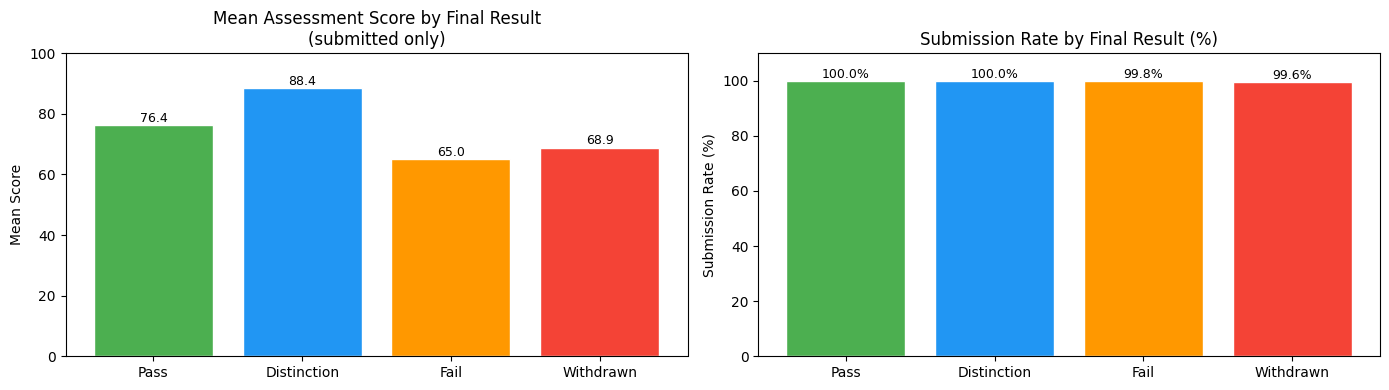

C:\Users\shawn\AppData\Local\Temp\ipykernel_12384\1984850963.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=order_present, patch_artist=True, notch=False,


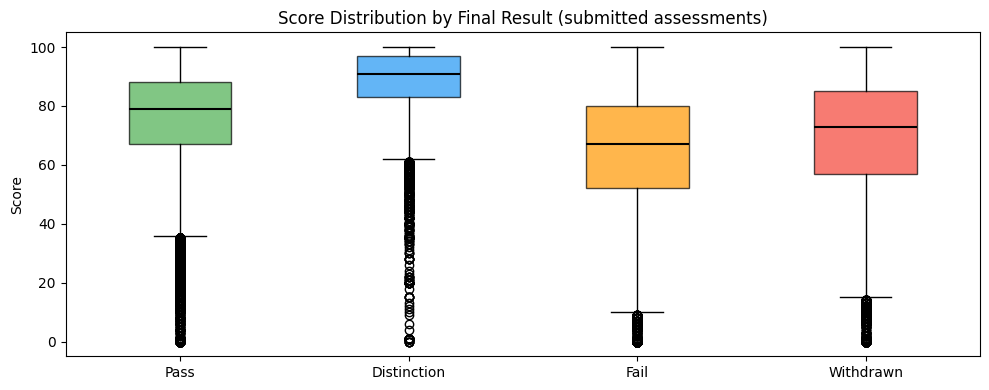

In [36]:

# ── Assessment type overview ───────────────────────────────────
print("── Assessment Types in Dataset ──")
assess_type_dist = assessments['assessment_type'].value_counts().reset_index()
assess_type_dist.columns = ['Type', 'Count']
assess_type_dist['%'] = (assess_type_dist['Count'] / len(assessments) * 100).round(1)
display(assess_type_dist)

# ── Join student_assess with assessment metadata + final_result ─
sa_full = (student_assess
    .merge(assessments[['id_assessment', 'assessment_type', 'weight']],
           on='id_assessment', how='left')
    .merge(student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
           on='id_student', how='left'))

# ── Submission rate by final result ───────────────────────────
print("\n── Submission Rate by Final Result ──")
sub_rate = (sa_full
    .groupby('final_result')
    .agg(Total_Records=('id_assessment', 'count'),
         Submitted=('submitted', 'sum'))
    .reset_index())
sub_rate['Submission Rate (%)'] = (sub_rate['Submitted'] / sub_rate['Total_Records'] * 100).round(1)
display(sub_rate)

# ── Mean score by assessment type × final result ──────────────
print("\n── Mean Score (submitted only) by Assessment Type × Final Result ──")
score_pivot = (sa_full[sa_full['submitted'] == 1]
    .groupby(['final_result', 'assessment_type'])['score']
    .mean().round(1)
    .unstack())
display(score_pivot)

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}

# Mean score by result
mean_scores = [sa_full[(sa_full['final_result']==r) & (sa_full['submitted']==1)]['score'].mean()
               for r in order]
bars = axes[0].bar(order, mean_scores, color=[palette[r] for r in order], edgecolor='white')
axes[0].set_title('Mean Assessment Score by Final Result\n(submitted only)')
axes[0].set_ylabel('Mean Score')
axes[0].set_ylim(0, 100)
for b, v in zip(bars, mean_scores):
    axes[0].text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}', ha='center', fontsize=9)

# Submission rate by result
sub_vals = [sub_rate[sub_rate['final_result']==r]['Submission Rate (%)'].values[0]
            if r in sub_rate['final_result'].values else 0 for r in order]
bars2 = axes[1].bar(order, sub_vals, color=[palette[r] for r in order], edgecolor='white')
axes[1].set_title('Submission Rate by Final Result (%)')
axes[1].set_ylabel('Submission Rate (%)')
axes[1].set_ylim(0, 110)
for b, v in zip(bars2, sub_vals):
    axes[1].text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Score distribution (box plots) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
order_present = [r for r in order if r in sa_full['final_result'].unique()]
data_box = [sa_full[(sa_full['final_result']==r) & (sa_full['submitted']==1)]['score'].dropna().values
            for r in order_present]
bp = ax.boxplot(data_box, labels=order_present, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, r in zip(bp['boxes'], order_present):
    patch.set_facecolor(palette[r])
    patch.set_alpha(0.7)
ax.set_title('Score Distribution by Final Result (submitted assessments)')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


## 7. Registration & Unregistration Timeline

── Registration Timing Summary ──


,Metric,Value
0,Total registrations,"32,593"
1,Students with unregistration date (withdrew),"10,072"
2,Registered before course start (date_reg < 0),"32,312"
3,Registered after course start (date_reg >= 0),236
4,Median registration day,-57
5,Withdrew before/on course start day,"3,097"
6,Withdrew after course started,"6,975"



── Mean Registration Day by Final Result ──


,Final Result,Mean Day,Median Day,Min Day,Max Day
0,Distinction,-65.6,-52.0,-303.0,32.0
1,Fail,-62.8,-50.0,-289.0,124.0
2,Pass,-66.7,-53.0,-310.0,101.0
3,Withdrawn,-78.4,-67.0,-322.0,167.0


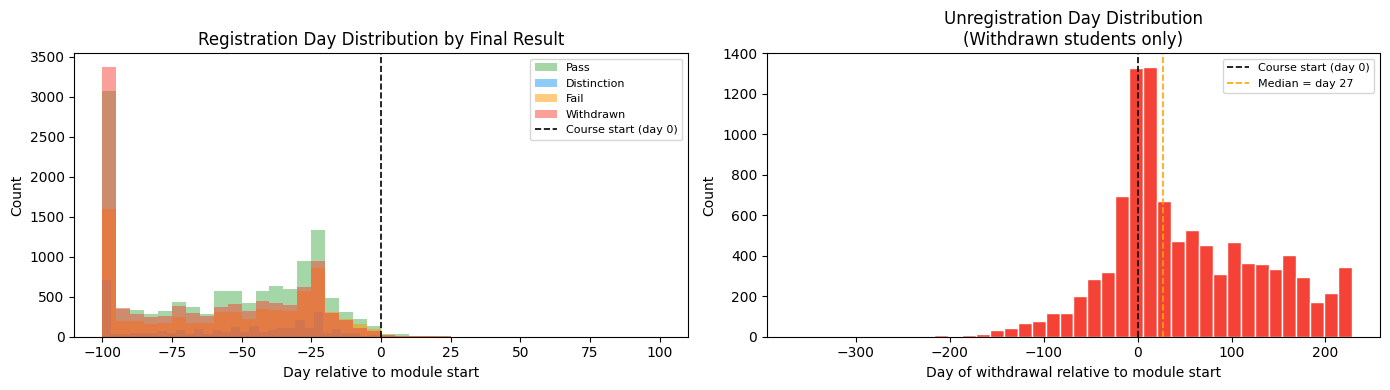


Withdrew before/on course start: 3,089 (30.7% of withdrawn with date)
Withdrew after course started:   6,974 (69.3% of withdrawn with date)


In [37]:

# ── Registration timing overview ──────────────────────────────
# date_registration: days relative to module start (negative = registered before start)
# date_unregistration: day of withdrawal; null if student did not withdraw
print("── Registration Timing Summary ──")
reg_stats = pd.DataFrame({
    'Metric': [
        'Total registrations',
        'Students with unregistration date (withdrew)',
        'Registered before course start (date_reg < 0)',
        'Registered after course start (date_reg >= 0)',
        'Median registration day',
        'Withdrew before/on course start day',
        'Withdrew after course started',
    ],
    'Value': [
        f"{len(student_reg):,}",
        f"{student_reg['date_unregistration'].notna().sum():,}",
        f"{(student_reg['date_registration'] < 0).sum():,}",
        f"{(student_reg['date_registration'] >= 0).sum():,}",
        f"{student_reg['date_registration'].median():.0f}",
        f"{(student_reg['date_unregistration'] <= 0).sum():,}",
        f"{(student_reg['date_unregistration'] > 0).sum():,}",
    ]
})
display(reg_stats)

# ── Join with final_result ─────────────────────────────────────
reg_full = student_reg.merge(
    student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left')

# ── Registration date by final result ─────────────────────────
print("\n── Mean Registration Day by Final Result ──")
reg_day_table = (reg_full
    .groupby('final_result')['date_registration']
    .agg(['mean', 'median', 'min', 'max'])
    .round(1)
    .reset_index())
reg_day_table.columns = ['Final Result', 'Mean Day', 'Median Day', 'Min Day', 'Max Day']
display(reg_day_table)

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}

# Registration day distribution by final result
for r in order:
    vals = reg_full[reg_full['final_result']==r]['date_registration'].dropna()
    axes[0].hist(vals.clip(-100, 100), bins=40, alpha=0.5, label=r,
                 color=palette[r], edgecolor='none')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Course start (day 0)')
axes[0].set_title('Registration Day Distribution by Final Result')
axes[0].set_xlabel('Day relative to module start')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Unregistration (withdrawal) day distribution
wd_unreg = reg_full[
    (reg_full['final_result'] == 'Withdrawn') &
    reg_full['date_unregistration'].notna()
]
p99_unreg = wd_unreg['date_unregistration'].quantile(0.99)
axes[1].hist(wd_unreg['date_unregistration'].clip(upper=p99_unreg),
             bins=40, color='#F44336', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Course start (day 0)')
axes[1].axvline(wd_unreg['date_unregistration'].median(), color='orange',
                linestyle='--', linewidth=1.2,
                label=f"Median = day {wd_unreg['date_unregistration'].median():.0f}")
axes[1].set_title('Unregistration Day Distribution\n(Withdrawn students only)')
axes[1].set_xlabel('Day of withdrawal relative to module start')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Early vs late withdrawal ──────────────────────────────────
early_wd = wd_unreg[wd_unreg['date_unregistration'] <= 0]
late_wd  = wd_unreg[wd_unreg['date_unregistration'] > 0]
print(f"\nWithdrew before/on course start: {len(early_wd):,} "
      f"({len(early_wd)/len(wd_unreg)*100:.1f}% of withdrawn with date)")
print(f"Withdrew after course started:   {len(late_wd):,} "
      f"({len(late_wd)/len(wd_unreg)*100:.1f}% of withdrawn with date)")


## 8. Representative Module Selection

In [3]:

# ── BBB vs FFF: Module selection decision matrix ───────────────
candidates = ['BBB', 'FFF']
pres_order = {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}

rows = []
for mod in candidates:
    df_mod = student_info[student_info['code_module'] == mod]
    presentations = sorted(df_mod['code_presentation'].unique(),
                           key=lambda x: pres_order.get(x, 99))
    n_pres = len(presentations)
    n_total = len(df_mod)

    # VLE coverage
    students_with_vle = set(student_vle[student_vle['code_module'] == mod]['id_student'].unique())
    vle_coverage = sum(1 for sid in df_mod['id_student'] if sid in students_with_vle) / n_total

    # Withdrawal rate
    wd_rate = (df_mod['final_result'] == 'Withdrawn').mean()

    # Click stats for VLE students
    vle_mod_agg = (student_vle[student_vle['code_module'] == mod]
                   .groupby('id_student')['sum_click'].sum())
    median_clicks = vle_mod_agg.median()

    rows.append({
        'Module': mod,
        'Presentations': ', '.join(presentations),
        'N (total)': n_total,
        'N per pres (avg)': round(n_total / n_pres),
        'VLE coverage %': f"{vle_coverage:.1%}",
        'Withdrawal rate': f"{wd_rate:.1%}",
        'Median clicks (VLE students)': f"{median_clicks:.0f}",
    })

df_compare = pd.DataFrame(rows)
print("── BBB vs FFF: Module Comparison ──")
display(df_compare)

# Per-presentation detail
print("\n── Per-presentation breakdown ──")
for mod in candidates:
    print(f"\n  {mod}:")
    for pres in sorted(student_info[student_info['code_module']==mod]['code_presentation'].unique(),
                       key=lambda x: pres_order.get(x, 99)):
        g = student_info[(student_info['code_module']==mod) & (student_info['code_presentation']==pres)]
        wd = (g['final_result']=='Withdrawn').mean()
        vle_n = student_vle[(student_vle['code_module']==mod) &
                             (student_vle['code_presentation']==pres)]['id_student'].nunique()
        print(f"    {pres}: n={len(g):,}  WD={wd:.1%}  VLE students={vle_n:,}  "
              f"VLE%={vle_n/len(g):.1%}")


── BBB vs FFF: Module Comparison ──


,Module,Presentations,N (total),N per pres (avg),VLE coverage %,Withdrawal rate,Median clicks (VLE students)
0,BBB,"2013B, 2013J, 2014B, 2014J",7909,1977,84.5%,30.2%,454
1,FFF,"2013B, 2013J, 2014B, 2014J",7762,1940,92.2%,31.0%,2116



── Per-presentation breakdown ──

  BBB:
    2013B: n=1,767  WD=28.6%  VLE students=1,537  VLE%=87.0%
    2013J: n=2,237  WD=28.8%  VLE students=1,870  VLE%=83.6%
    2014B: n=1,613  WD=30.4%  VLE students=1,294  VLE%=80.2%
    2014J: n=2,292  WD=32.7%  VLE students=1,921  VLE%=83.8%

  FFF:
    2013B: n=1,614  WD=25.5%  VLE students=1,510  VLE%=93.6%
    2013J: n=2,283  WD=29.6%  VLE students=2,098  VLE%=91.9%
    2014B: n=1,500  WD=30.8%  VLE students=1,363  VLE%=90.9%
    2014J: n=2,365  WD=36.2%  VLE students=2,121  VLE%=89.7%


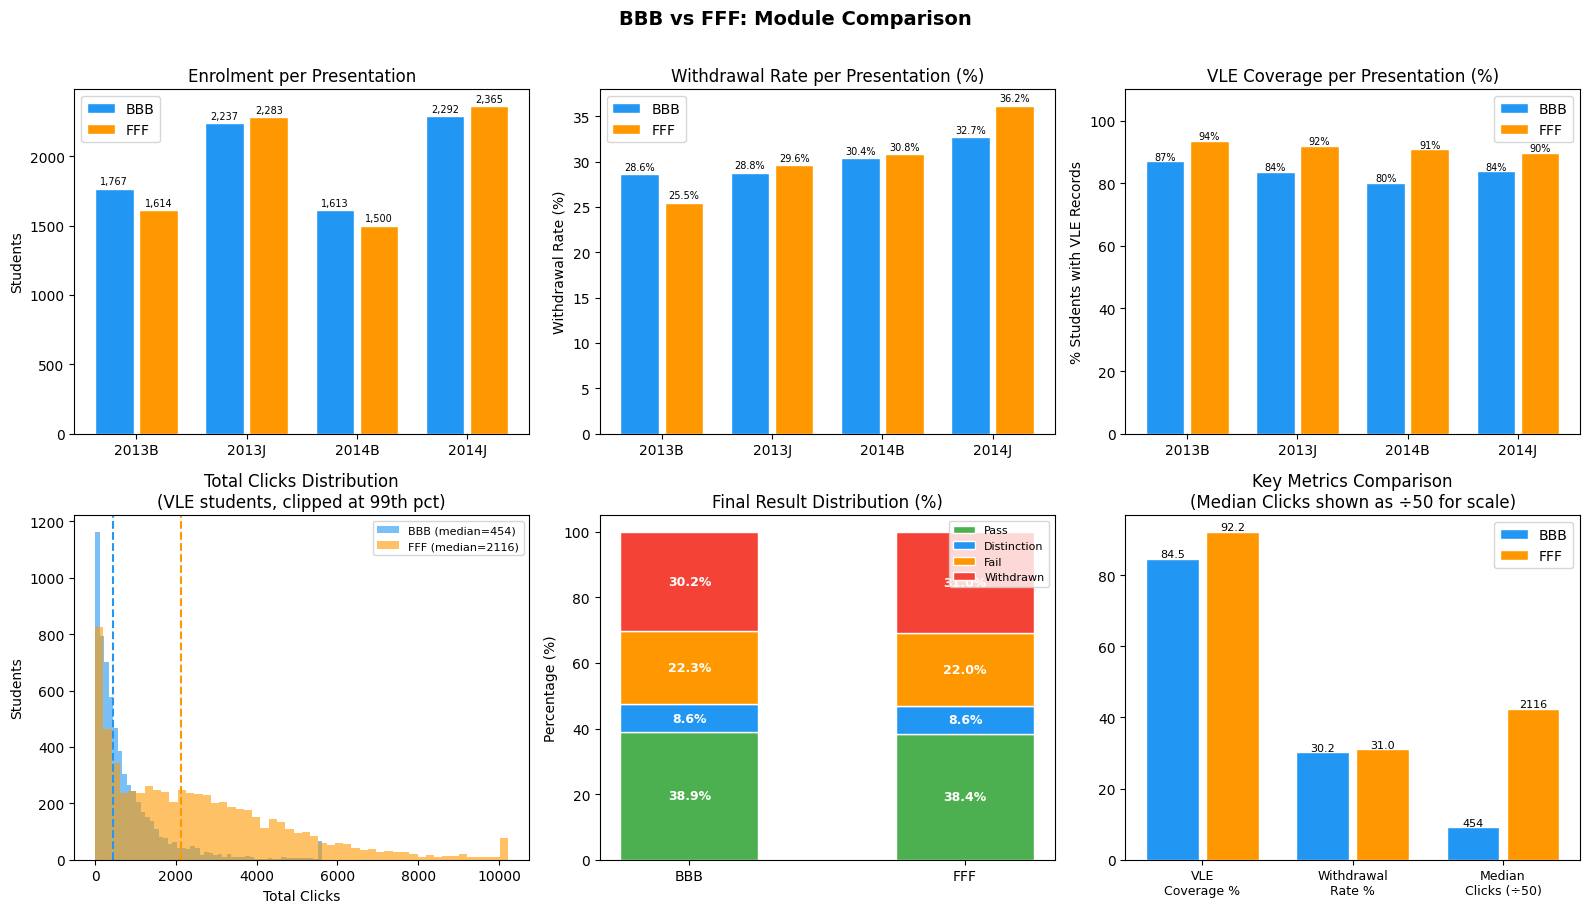


Conclusion: FFF selected — higher VLE coverage (92.2%) and richer click signal (median 2116 vs 454)


In [5]:

# ── BBB vs FFF: Visual Comparison ─────────────────────────────
pres_order = {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}
candidates = ['BBB', 'FFF']
palette_mod = {'BBB': '#2196F3', 'FFF': '#FF9800'}
presentations = ['2013B', '2013J', '2014B', '2014J']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('BBB vs FFF: Module Comparison', fontsize=14, fontweight='bold', y=1.01)

# ── (0,0) Enrolment per presentation ──────────────────────────
for mod in candidates:
    counts = []
    for pres in presentations:
        n = len(student_info[(student_info['code_module']==mod) &
                              (student_info['code_presentation']==pres)])
        counts.append(n)
    x = np.arange(len(presentations))
    offset = -0.2 if mod == 'BBB' else 0.2
    bars = axes[0,0].bar(x + offset, counts, width=0.35,
                          label=mod, color=palette_mod[mod], edgecolor='white')
    for b, v in zip(bars, counts):
        if v > 0:
            axes[0,0].text(b.get_x()+b.get_width()/2, v+30, f'{v:,}',
                           ha='center', fontsize=7)
axes[0,0].set_xticks(np.arange(len(presentations)))
axes[0,0].set_xticklabels(presentations)
axes[0,0].set_title('Enrolment per Presentation')
axes[0,0].set_ylabel('Students')
axes[0,0].legend()

# ── (0,1) Withdrawal rate per presentation ────────────────────
for mod in candidates:
    wd_rates = []
    for pres in presentations:
        g = student_info[(student_info['code_module']==mod) &
                         (student_info['code_presentation']==pres)]
        wd_rates.append((g['final_result']=='Withdrawn').mean() * 100 if len(g) > 0 else 0)
    x = np.arange(len(presentations))
    offset = -0.2 if mod == 'BBB' else 0.2
    bars = axes[0,1].bar(x + offset, wd_rates, width=0.35,
                          label=mod, color=palette_mod[mod], edgecolor='white')
    for b, v in zip(bars, wd_rates):
        if v > 0:
            axes[0,1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%',
                           ha='center', fontsize=7)
axes[0,1].set_xticks(np.arange(len(presentations)))
axes[0,1].set_xticklabels(presentations)
axes[0,1].set_title('Withdrawal Rate per Presentation (%)')
axes[0,1].set_ylabel('Withdrawal Rate (%)')
axes[0,1].legend()

# ── (0,2) VLE coverage per presentation ───────────────────────
for mod in candidates:
    vle_pcts = []
    for pres in presentations:
        g = student_info[(student_info['code_module']==mod) &
                         (student_info['code_presentation']==pres)]
        if len(g) == 0:
            vle_pcts.append(0); continue
        vle_ids = set(student_vle[(student_vle['code_module']==mod) &
                                   (student_vle['code_presentation']==pres)]['id_student'].unique())
        vle_pcts.append(sum(1 for s in g['id_student'] if s in vle_ids) / len(g) * 100)
    x = np.arange(len(presentations))
    offset = -0.2 if mod == 'BBB' else 0.2
    bars = axes[0,2].bar(x + offset, vle_pcts, width=0.35,
                          label=mod, color=palette_mod[mod], edgecolor='white')
    for b, v in zip(bars, vle_pcts):
        if v > 0:
            axes[0,2].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%',
                           ha='center', fontsize=7)
axes[0,2].set_xticks(np.arange(len(presentations)))
axes[0,2].set_xticklabels(presentations)
axes[0,2].set_title('VLE Coverage per Presentation (%)')
axes[0,2].set_ylabel('% Students with VLE Records')
axes[0,2].set_ylim(0, 110)
axes[0,2].legend()

# ── (1,0) Click distribution (VLE students, all presentations) ─
for mod in candidates:
    clicks = (student_vle[student_vle['code_module'] == mod]
              .groupby('id_student')['sum_click'].sum())
    p99 = clicks.quantile(0.99)
    axes[1,0].hist(clicks.clip(upper=p99), bins=50, alpha=0.6,
                   label=f'{mod} (median={clicks.median():.0f})',
                   color=palette_mod[mod], edgecolor='none')
    axes[1,0].axvline(clicks.median(), color=palette_mod[mod],
                      linestyle='--', linewidth=1.5)
axes[1,0].set_title('Total Clicks Distribution\n(VLE students, clipped at 99th pct)')
axes[1,0].set_xlabel('Total Clicks')
axes[1,0].set_ylabel('Students')
axes[1,0].legend(fontsize=8)

# ── (1,1) Final result breakdown side-by-side stacked bar ─────
result_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
result_palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}
x = np.arange(len(candidates))
bottoms = np.zeros(len(candidates))
for res in result_order:
    vals = []
    for mod in candidates:
        g = student_info[student_info['code_module'] == mod]
        vals.append((g['final_result']==res).mean() * 100)
    axes[1,1].bar(x, vals, bottom=bottoms, label=res,
                  color=result_palette[res], edgecolor='white', width=0.5)
    for i, v in enumerate(vals):
        if v > 3:
            axes[1,1].text(x[i], bottoms[i] + v/2, f'{v:.1f}%',
                           ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(candidates)
axes[1,1].set_title('Final Result Distribution (%)')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].legend(loc='upper right', fontsize=8)

# ── (1,2) Summary radar / summary bar ─────────────────────────
metrics = ['VLE\nCoverage %', 'Withdrawal\nRate %', 'Median\nClicks (÷50)']
bbb_vals = [84.5, 30.2, 454/50]
fff_vals = [92.2, 31.0, 2116/50]
x = np.arange(len(metrics))
axes[1,2].bar(x - 0.2, bbb_vals, width=0.35, label='BBB', color=palette_mod['BBB'], edgecolor='white')
axes[1,2].bar(x + 0.2, fff_vals, width=0.35, label='FFF', color=palette_mod['FFF'], edgecolor='white')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metrics, fontsize=9)
axes[1,2].set_title('Key Metrics Comparison\n(Median Clicks shown as ÷50 for scale)')
axes[1,2].legend()
for xi, (bv, fv) in enumerate(zip(bbb_vals, fff_vals)):
    raw_b = [84.5, 30.2, 454][xi]
    raw_f = [92.2, 31.0, 2116][xi]
    axes[1,2].text(xi-0.2, bv+0.5, f'{raw_b}', ha='center', fontsize=8)
    axes[1,2].text(xi+0.2, fv+0.5, f'{raw_f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print("\nConclusion: FFF selected — higher VLE coverage (92.2%) and richer click signal (median 2116 vs 454)")


## 9. B1 — Raw-Feature XGBoost Baseline (FFF Module)

In [4]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             precision_recall_fscore_support)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

TARGET_MODULE = 'FFF'

# ── 1. Filter to FFF module ────────────────────────────────────
si_fff = student_info[student_info['code_module'] == TARGET_MODULE].copy()
sv_fff = student_vle[student_vle['code_module'] == TARGET_MODULE].copy()

# FFF assessments → filter student_assess to matching id_assessment
assess_fff_ids = assessments[assessments['code_module'] == TARGET_MODULE]['id_assessment']
sa_fff = student_assess[student_assess['id_assessment'].isin(assess_fff_ids)].copy()

# ── 2. Per-student VLE aggregates ─────────────────────────────
vle_feats = sv_fff.groupby('id_student').agg(
    total_clicks      = ('sum_click', 'sum'),
    active_days       = ('date', 'nunique'),
    mean_daily_clicks = ('sum_click', 'mean'),
    max_daily_clicks  = ('sum_click', 'max'),
    unique_resources  = ('id_site', 'nunique'),
).reset_index()

# ── 3. Assessment aggregates ──────────────────────────────────
assess_feats = sa_fff.groupby('id_student').agg(
    mean_score      = ('score', 'mean'),
    num_submissions = ('id_assessment', 'count'),
).reset_index()

# ── 4. Build feature matrix (keep code_presentation for temporal split) ──
df_b1 = (si_fff[['id_student', 'code_presentation', 'gender', 'age_band',
                  'highest_education', 'imd_band', 'disability', 'final_result']]
         .merge(vle_feats,    on='id_student', how='left')
         .merge(assess_feats, on='id_student', how='left'))

# ── 5. Fill missing VLE / assessment values with 0 ────────────
fill_cols = ['total_clicks', 'active_days', 'mean_daily_clicks',
             'max_daily_clicks', 'unique_resources', 'mean_score', 'num_submissions']
df_b1[fill_cols] = df_b1[fill_cols].fillna(0)

# ── 6. Binary label: Withdrawn = 1, otherwise = 0 ─────────────
df_b1['label'] = (df_b1['final_result'] == 'Withdrawn').astype(int)

# ── 7. Encode categorical features ────────────────────────────
cat_cols = ['gender', 'age_band', 'highest_education', 'imd_band', 'disability']
df_b1[cat_cols] = df_b1[cat_cols].astype('category')
for c in cat_cols:
    df_b1[c] = df_b1[c].cat.codes

feature_cols_b1 = fill_cols + cat_cols

print(f"Module: {TARGET_MODULE}  |  Samples: {len(df_b1):,}  |  Features: {len(feature_cols_b1)}")
print(f"Class balance — Withdrawn: {df_b1['label'].mean():.1%}  |  Not withdrawn: {1 - df_b1['label'].mean():.1%}")

print("\n── Presentation breakdown ──")
pres_summary = (df_b1.groupby('code_presentation')
    .agg(N=('label', 'count'), WD_rate=('label', 'mean'))
    .rename(columns={'WD_rate': 'Withdrawal Rate'})
    .assign(**{'Withdrawal Rate': lambda d: d['Withdrawal Rate'].map('{:.1%}'.format)})
    .reindex(['2013B', '2013J', '2014B', '2014J']))
display(pres_summary)


Module: FFF  |  Samples: 7,762  |  Features: 12
Class balance — Withdrawn: 31.0%  |  Not withdrawn: 69.0%

── Presentation breakdown ──


,N,Withdrawal Rate
code_presentation,,
2013B,1614,25.5%
2013J,2283,29.6%
2014B,1500,30.8%
2014J,2365,36.2%


── Temporal Split Summary ──


,Split,N,Withdrawal Rate
0,Train (2013B + 2013J),3897,27.9%
1,Test (2014B + 2014J),3865,34.1%



── B1 XGBoost Baseline (True Library Defaults): Performance Metrics ──


,Metric,Score
0,Accuracy,0.8057
1,Precision (macro),0.7837
2,Recall (macro),0.7969
3,macro-F1,0.7890
4,AUC-ROC,0.8873



── Per-Class Report ──


,Class,Precision,Recall,F1-Score,Support
0,Not Withdrawn (0),0.8736,0.8246,0.8484,2548
1,Withdrawn (1),0.6938,0.7692,0.7296,1317


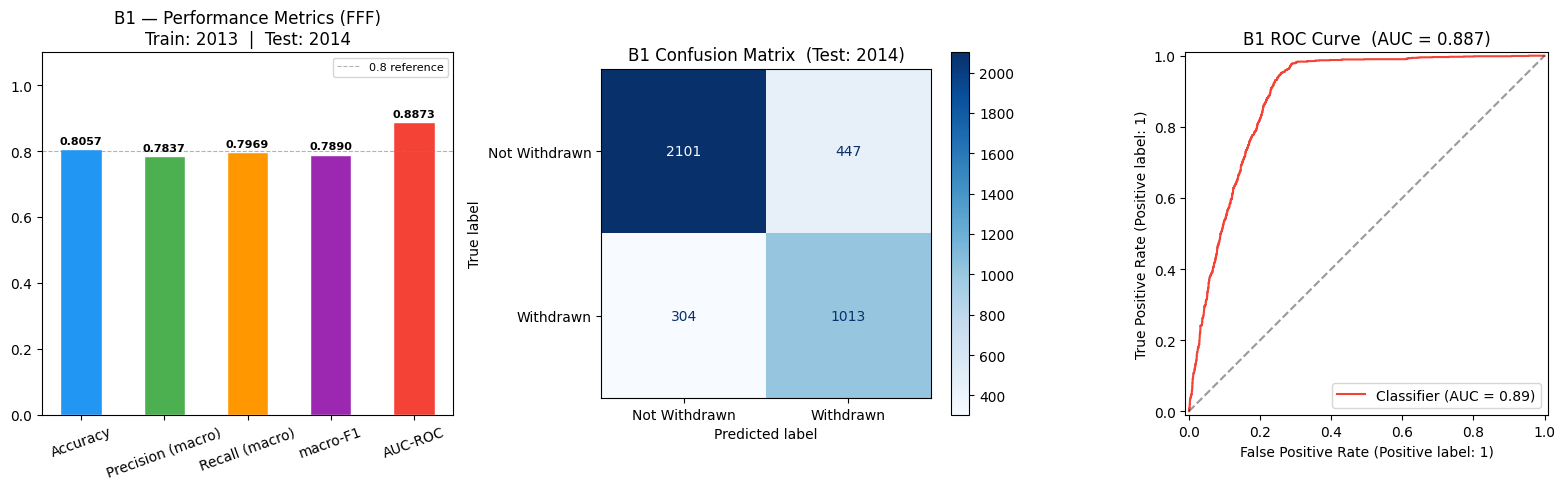

In [5]:
# ── 8. Temporal Train/Test Split (2013 → train, 2014 → test) ──
train_mask = df_b1['code_presentation'].str.startswith('2013')
test_mask  = df_b1['code_presentation'].str.startswith('2014')

X_train_b1 = df_b1.loc[train_mask, feature_cols_b1].values
y_train_b1 = df_b1.loc[train_mask, 'label'].values
X_test_b1  = df_b1.loc[test_mask,  feature_cols_b1].values
y_test_b1  = df_b1.loc[test_mask,  'label'].values

print("── Temporal Split Summary ──")
display(pd.DataFrame({
    'Split':           ['Train (2013B + 2013J)', 'Test  (2014B + 2014J)'],
    'N':               [len(y_train_b1), len(y_test_b1)],
    'Withdrawal Rate': [f'{y_train_b1.mean():.1%}', f'{y_test_b1.mean():.1%}'],
}))

# ── 9. Train XGBoost — XGBoost true library defaults ──────────
model_b1 = XGBClassifier(
    n_estimators=100,       
    max_depth=6,           
    learning_rate=0.3,      
    subsample=1.0,          
    colsample_bytree=1.0,   
    gamma=0,               
    reg_alpha=0,            
    reg_lambda=1,           
    min_child_weight=1,     
    scale_pos_weight=(y_train_b1 == 0).sum() / (y_train_b1 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_b1.fit(X_train_b1, y_train_b1)

y_pred_b1  = model_b1.predict(X_test_b1)
y_proba_b1 = model_b1.predict_proba(X_test_b1)[:, 1]

# ── 10. Metrics ───────────────────────────────────────────────
acc_b1   = accuracy_score(y_test_b1, y_pred_b1)
prec_b1  = precision_score(y_test_b1, y_pred_b1, average='macro')
rec_b1   = recall_score(y_test_b1, y_pred_b1, average='macro')
f1_b1    = f1_score(y_test_b1, y_pred_b1, average='macro')
auc_b1   = roc_auc_score(y_test_b1, y_proba_b1)

print("\n── B1 XGBoost Baseline (True Library Defaults): Performance Metrics ──")
metrics_b1 = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Score':  [acc_b1, prec_b1, rec_b1, f1_b1, auc_b1],
})
metrics_b1['Score'] = metrics_b1['Score'].round(4)
display(metrics_b1)

# Per-class report
p2, r2, f2, s2 = precision_recall_fscore_support(y_test_b1, y_pred_b1, labels=[0, 1])
print("\n── Per-Class Report ──")
display(pd.DataFrame({
    'Class':     ['Not Withdrawn (0)', 'Withdrawn (1)'],
    'Precision': p2.round(4),
    'Recall':    r2.round(4),
    'F1-Score':  f2.round(4),
    'Support':   s2,
}))

# ── 11. Charts ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Metrics bar chart
colors_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[0].bar(metrics_b1['Metric'], metrics_b1['Score'],
                   color=colors_m, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'B1 — Performance Metrics ({TARGET_MODULE})\nTrain: 2013  |  Test: 2014')
axes[0].axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='0.8 reference')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)
for b, v in zip(bars, metrics_b1['Score']):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_b1, y_pred_b1,
    display_labels=['Not Withdrawn', 'Withdrawn'],
    cmap='Blues', ax=axes[1])
axes[1].set_title('B1 Confusion Matrix  (Test: 2014)')

# ROC curve
RocCurveDisplay.from_predictions(y_test_b1, y_proba_b1, ax=axes[2], color='#F44336')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_title(f'B1 ROC Curve  (AUC = {auc_b1:.3f})')

plt.tight_layout()
plt.show()


## 10. B1 Ablation — Effect of Removing imd_band

In [6]:
# ── B1 without imd_band (11 features) ────────────────────────
# imd_band is a socioeconomic deprivation index that may introduce
# demographic bias. This ablation tests its marginal contribution.

feature_cols_no_imd = [c for c in feature_cols_b1 if c != 'imd_band']

X_train_no_imd = df_b1.loc[train_mask, feature_cols_no_imd].values
X_test_no_imd  = df_b1.loc[test_mask,  feature_cols_no_imd].values

print(f"Features with imd_band: {len(feature_cols_b1)}  →  without: {len(feature_cols_no_imd)}")
print(f"Dropped: imd_band")

# ── Train with true XGBoost defaults (no imd_band) ────────────
model_no_imd = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    min_child_weight=1,
    scale_pos_weight=(y_train_b1 == 0).sum() / (y_train_b1 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_no_imd.fit(X_train_no_imd, y_train_b1)

y_pred_no_imd  = model_no_imd.predict(X_test_no_imd)
y_proba_no_imd = model_no_imd.predict_proba(X_test_no_imd)[:, 1]

acc_ni  = accuracy_score(y_test_b1, y_pred_no_imd)
prec_ni = precision_score(y_test_b1, y_pred_no_imd, average='macro')
rec_ni  = recall_score(y_test_b1, y_pred_no_imd, average='macro')
f1_ni   = f1_score(y_test_b1, y_pred_no_imd, average='macro')
auc_ni  = roc_auc_score(y_test_b1, y_proba_no_imd)

# ── 2-way comparison: Default with vs. without imd_band ───────
ablation_df = pd.DataFrame({
    'Metric':               ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 Default (w/ imd)': [acc_b1, prec_b1, rec_b1, f1_b1, auc_b1],
    'B1 Default (no imd)': [acc_ni, prec_ni, rec_ni, f1_ni, auc_ni],
})
ablation_df['Δ (no imd − w/ imd)'] = (
    ablation_df['B1 Default (no imd)'] - ablation_df['B1 Default (w/ imd)']
).map(lambda x: f"{x:+.4f}")
for col in ['B1 Default (w/ imd)', 'B1 Default (no imd)']:
    ablation_df[col] = ablation_df[col].map('{:.4f}'.format)

print("── imd_band Ablation: Default model with vs. without imd_band ──")
display(ablation_df)


Features with imd_band: 12  →  without: 11
Dropped: imd_band
── imd_band Ablation: Default model with vs. without imd_band ──


,Metric,B1 Default (w/ imd),B1 Default (no imd),Δ (no imd − w/ imd)
0,Accuracy,0.8057,0.8065,+0.0008
1,Precision (macro),0.7837,0.7844,+0.0006
2,Recall (macro),0.7969,0.7960,-0.0009
3,macro-F1,0.7890,0.7892,+0.0002
4,AUC-ROC,0.8873,0.8893,+0.0020


## 11. B1 Default Model (Without imd_band) — Full Evaluation

── B1 Default (no imd_band): Performance Metrics ──


,Metric,Score
0,Accuracy,0.8065
1,Precision (macro),0.7844
2,Recall (macro),0.7960
3,macro-F1,0.7892
4,AUC-ROC,0.8893



── Per-Class Report ──


,Class,Precision,Recall,F1-Score,Support
0,Not Withdrawn (0),0.8713,0.8289,0.8496,2548
1,Withdrawn (1),0.6974,0.7631,0.7288,1317


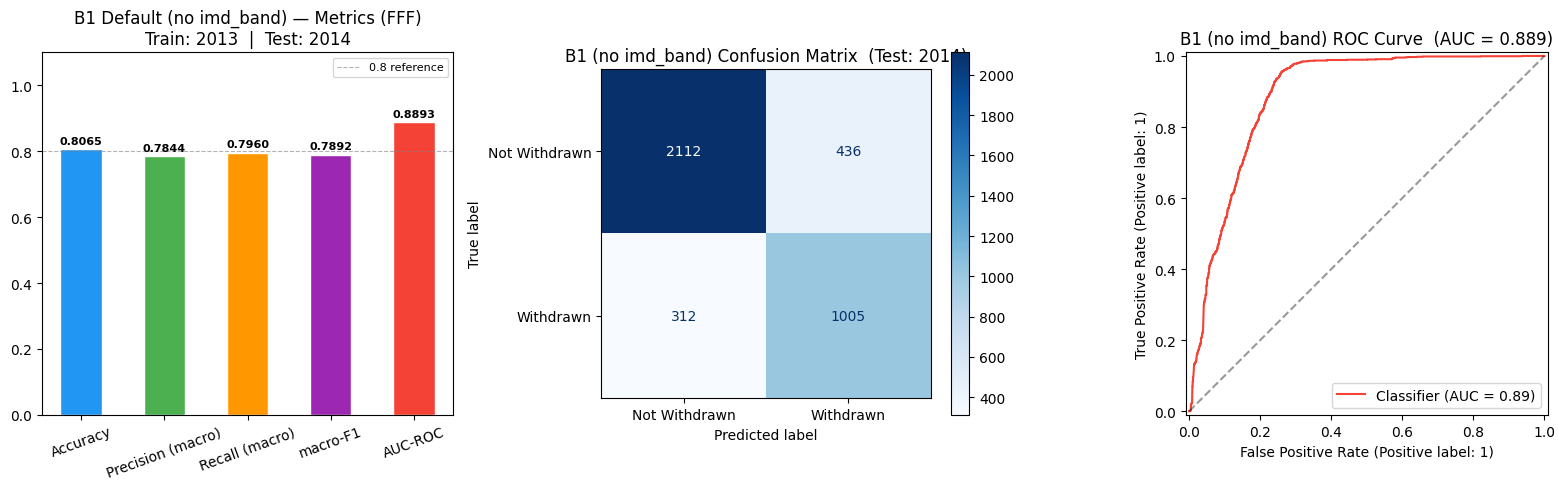

In [7]:
# ── Full evaluation of default XGBoost model without imd_band ─
# model_no_imd / X_train_no_imd / X_test_no_imd already built in Section 10

print("── B1 Default (no imd_band): Performance Metrics ──")
metrics_ni = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Score':  [acc_ni, prec_ni, rec_ni, f1_ni, auc_ni],
})
metrics_ni['Score'] = metrics_ni['Score'].round(4)
display(metrics_ni)

# Per-class report
p_ni, r_ni, f_ni, s_ni = precision_recall_fscore_support(y_test_b1, y_pred_no_imd, labels=[0, 1])
print("\n── Per-Class Report ──")
display(pd.DataFrame({
    'Class':     ['Not Withdrawn (0)', 'Withdrawn (1)'],
    'Precision': p_ni.round(4),
    'Recall':    r_ni.round(4),
    'F1-Score':  f_ni.round(4),
    'Support':   s_ni,
}))

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[0].bar(metrics_ni['Metric'], metrics_ni['Score'],
                   color=colors_m, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'B1 Default (no imd_band) — Metrics ({TARGET_MODULE})\nTrain: 2013  |  Test: 2014')
axes[0].axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='0.8 reference')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)
for b, v in zip(bars, metrics_ni['Score']):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test_b1, y_pred_no_imd,
    display_labels=['Not Withdrawn', 'Withdrawn'],
    cmap='Blues', ax=axes[1])
axes[1].set_title('B1 (no imd_band) Confusion Matrix  (Test: 2014)')

RocCurveDisplay.from_predictions(y_test_b1, y_proba_no_imd, ax=axes[2], color='#F44336')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_title(f'B1 (no imd_band) ROC Curve  (AUC = {auc_ni:.3f})')

plt.tight_layout()
plt.show()


## 12. B1 — Hyperparameter Tuning (RandomizedSearchCV on 2013 Train Set, Without imd_band)

In [8]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
import warnings; warnings.filterwarnings('ignore')

# ── Parameter search space ──
param_dist = {
    'n_estimators':     randint(100, 501),   # 100–500 trees
    'max_depth':        randint(3, 9),        # depth 3–8
    'learning_rate':    uniform(0.01, 0.29),  # 0.01–0.30
    'subsample':        uniform(0.60, 0.40),  # 0.60–1.00
    'colsample_bytree': uniform(0.60, 0.40),  # 0.60–1.00
    'min_child_weight': randint(1, 11),       # 1–10
    'gamma':            uniform(0, 5),        # 0–5
    'reg_alpha':        uniform(0, 1),        # L1 0–1
    'reg_lambda':       uniform(0.5, 2.5),    # L2 0.5–3.0
}

# ── Base estimator (same class-imbalance correction, no imd_band) ──
pos_weight = float((y_train_b1 == 0).sum()) / float((y_train_b1 == 1).sum())
base_xgb = XGBClassifier(
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

# ── 5-fold stratified CV *on training data only* (2013B + 2013J) ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=50,              # 50 random configs × 5 folds = 250 fits
    scoring='f1_macro',     # optimise the same metric we report
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,             # re-trains best params on full X_train_no_imd
)

print("Running RandomizedSearchCV  (50 iterations × 5 folds = 250 fits)…")
search.fit(X_train_no_imd, y_train_b1)

print(f"\nBest CV macro-F1 (on 2013 train): {search.best_score_:.4f}")
print("\nBest parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:22s}: {v}")


Running RandomizedSearchCV  (50 iterations × 5 folds = 250 fits)…
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV macro-F1 (on 2013 train): 0.7988

Best parameters:
  colsample_bytree      : 0.7712736593269257
  gamma                 : 4.833274095218348
  learning_rate         : 0.28944979335588333
  max_depth             : 3
  min_child_weight      : 4
  n_estimators          : 290
  reg_alpha             : 0.30569701928718185
  reg_lambda            : 0.9772775778758651
  subsample             : 0.7073899427560627


In [9]:
# ── Evaluate tuned model on held-out 2014 test set (no imd_band) ──
model_b1_tuned = search.best_estimator_

y_pred_tuned  = model_b1_tuned.predict(X_test_no_imd)
y_proba_tuned = model_b1_tuned.predict_proba(X_test_no_imd)[:, 1]

acc_t  = accuracy_score(y_test_b1, y_pred_tuned)
prec_t = precision_score(y_test_b1, y_pred_tuned, average='macro')
rec_t  = recall_score(y_test_b1, y_pred_tuned, average='macro')
f1_t   = f1_score(y_test_b1, y_pred_tuned, average='macro')
auc_t  = roc_auc_score(y_test_b1, y_proba_tuned)

# ── Side-by-side comparison: Default (no imd) vs Tuned (no imd) ──
compare_df = pd.DataFrame({
    'Metric':                ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 Default (no imd)':  [acc_ni,  prec_ni,  rec_ni,  f1_ni,  auc_ni],
    'B1 Tuned (no imd)':    [acc_t,   prec_t,   rec_t,   f1_t,   auc_t],
})
compare_df['Δ (Tuned − Default)'] = (
    compare_df['B1 Tuned (no imd)'] - compare_df['B1 Default (no imd)']
).map(lambda x: f"{x:+.4f}")
compare_df['B1 Default (no imd)'] = compare_df['B1 Default (no imd)'].map('{:.4f}'.format)
compare_df['B1 Tuned (no imd)']   = compare_df['B1 Tuned (no imd)'].map('{:.4f}'.format)
display(compare_df)

print(f"\nTuned model (no imd)  →  macro-F1 = {f1_t:.4f}  |  AUC-ROC = {auc_t:.4f}")


,Metric,B1 Default (no imd),B1 Tuned (no imd),Δ (Tuned − Default)
0,Accuracy,0.8065,0.8261,+0.0197
1,Precision (macro),0.7844,0.8137,+0.0294
2,Recall (macro),0.7960,0.8459,+0.0499
3,macro-F1,0.7892,0.8183,+0.0292
4,AUC-ROC,0.8893,0.9082,+0.0189



Tuned model (no imd)  →  macro-F1 = 0.8183  |  AUC-ROC = 0.9082


## 13. B1 — Bayesian Optimisation (Optuna TPE, 50 Trials, Without imd_band)

In [10]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_weight_op = float((y_train_b1 == 0).sum()) / float((y_train_b1 == 1).sum())

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.30),
        'subsample':        trial.suggest_float('subsample', 0.60, 1.00),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
    }
    clf = XGBClassifier(
        **params,
        scale_pos_weight=pos_weight_op,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    cv_op = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train_no_imd, y_train_b1,
                             cv=cv_op, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print("Running Optuna TPE  (50 trials × 5 folds = 250 fits)…")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest CV macro-F1 (Optuna): {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in sorted(study.best_params.items()):
    print(f"  {k:22s}: {v}")


Running Optuna TPE  (50 trials × 5 folds = 250 fits)…


  0%|          | 0/50 [00:00<?, ?it/s]


Best CV macro-F1 (Optuna): 0.7979

Best parameters:
  colsample_bytree      : 0.9982299493520854
  gamma                 : 3.802480481075314
  learning_rate         : 0.15627877563449813
  max_depth             : 7
  min_child_weight      : 8
  n_estimators          : 238
  reg_alpha             : 0.8867344047705905
  reg_lambda            : 1.017105897002601
  subsample             : 0.6272040061323861


In [11]:
# ── Evaluate Optuna model on held-out 2014 test set ───────────
model_b1_optuna = XGBClassifier(
    **study.best_params,
    scale_pos_weight=pos_weight_op,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_b1_optuna.fit(X_train_no_imd, y_train_b1)

y_pred_op  = model_b1_optuna.predict(X_test_no_imd)
y_proba_op = model_b1_optuna.predict_proba(X_test_no_imd)[:, 1]

acc_op  = accuracy_score(y_test_b1, y_pred_op)
prec_op = precision_score(y_test_b1, y_pred_op, average='macro')
rec_op  = recall_score(y_test_b1, y_pred_op, average='macro')
f1_op   = f1_score(y_test_b1, y_pred_op, average='macro')
auc_op  = roc_auc_score(y_test_b1, y_proba_op)

# ── 3-way comparison ──────────────────────────────────────────
final_df = pd.DataFrame({
    'Metric':             ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Default (no imd)':   [acc_ni,  prec_ni,  rec_ni,  f1_ni,  auc_ni],
    'RandomizedSearchCV': [acc_t,   prec_t,   rec_t,   f1_t,   auc_t],
    'Optuna (Bayesian)':  [acc_op,  prec_op,  rec_op,  f1_op,  auc_op],
})
for col in ['Default (no imd)', 'RandomizedSearchCV', 'Optuna (Bayesian)']:
    final_df[col] = final_df[col].map('{:.4f}'.format)

print("── B1 Final Comparison: Default vs RandomizedSearchCV vs Optuna ──")
display(final_df)
print(f"\nRandomizedSearchCV  →  macro-F1 = {f1_t:.4f}  |  AUC = {auc_t:.4f}")
print(f"Optuna (Bayesian)   →  macro-F1 = {f1_op:.4f}  |  AUC = {auc_op:.4f}")


── B1 Final Comparison: Default vs RandomizedSearchCV vs Optuna ──


,Metric,Default (no imd),RandomizedSearchCV,Optuna (Bayesian)
0,Accuracy,0.8065,0.8261,0.8197
1,Precision (macro),0.7844,0.8137,0.8076
2,Recall (macro),0.7960,0.8459,0.8394
3,macro-F1,0.7892,0.8183,0.8117
4,AUC-ROC,0.8893,0.9082,0.9074



RandomizedSearchCV  →  macro-F1 = 0.8183  |  AUC = 0.9082
Optuna (Bayesian)   →  macro-F1 = 0.8117  |  AUC = 0.9074
